In [1]:
import pandas as pd

df = pd.read_csv('AI-small-data.csv', index_col = 0)
df

,0,1,2,3,4,5,6,7,8,9,...,8774,8775,8776,8777,8778,8779,8780,8781,8782,8783
page_title,,,,,,,,,,,,,,,,,,,,,
Artificial_intelligence,107.0,97.0,95.0,107.0,139.0,137.0,191.0,181.0,207.0,197.0,...,172.0,189.0,209.0,166.0,160.0,145.0,124.0,135.0,129.0,91.0
Bayesian_network,2.0,0.0,10.0,1.0,4.0,2.0,3.0,8.0,8.0,4.0,...,9.0,8.0,5.0,8.0,6.0,11.0,8.0,2.0,4.0,5.0
Computer_vision,5.0,13.0,16.0,7.0,5.0,12.0,15.0,8.0,10.0,10.0,...,10.0,12.0,13.0,10.0,13.0,16.0,7.0,5.0,6.0,5.0
Deep_learning,19.0,33.0,17.0,18.0,20.0,20.0,23.0,26.0,29.0,25.0,...,26.0,32.0,41.0,22.0,23.0,23.0,18.0,20.0,14.0,19.0
Generative_artificial_intelligence,15.0,28.0,15.0,12.0,18.0,29.0,17.0,19.0,18.0,26.0,...,59.0,63.0,58.0,59.0,38.0,41.0,34.0,38.0,46.0,36.0
Language_model,2.0,2.0,6.0,2.0,1.0,5.0,1.0,7.0,3.0,0.0,...,8.0,10.0,5.0,12.0,4.0,6.0,6.0,3.0,3.0,1.0
Machine_learning,39.0,21.0,38.0,33.0,36.0,48.0,58.0,68.0,81.0,93.0,...,61.0,70.0,72.0,76.0,68.0,66.0,45.0,41.0,38.0,29.0
Markov_decision_process,7.0,10.0,8.0,4.0,7.0,3.0,4.0,2.0,2.0,4.0,...,4.0,7.0,10.0,15.0,11.0,8.0,4.0,10.0,8.0,8.0
Mathematical_optimization,6.0,9.0,12.0,4.0,6.0,3.0,11.0,4.0,10.0,8.0,...,10.0,10.0,18.0,5.0,9.0,10.0,5.0,10.0,10.0,10.0


In [2]:
import numpy as np

def compute_mape(var, var_hat):
    return np.sum(np.abs(var - var_hat) / var) / var.shape[0]

def compute_rmse(var, var_hat):
    return np.sqrt(np.sum((var - var_hat) ** 2) / var.shape[0])

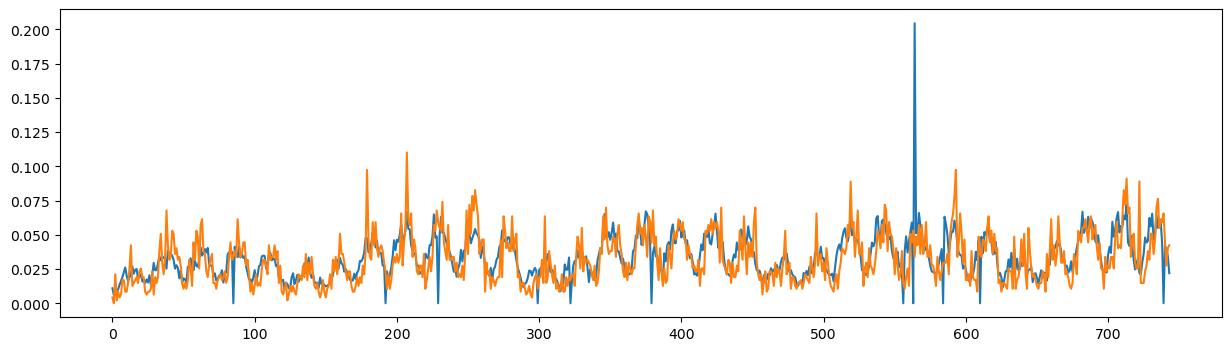

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x / np.linalg.norm(x, 2))
x = df.loc['Bayesian_network'].values[: 24 * 31]
plt.plot(x / np.linalg.norm(x, 2))
plt.show()

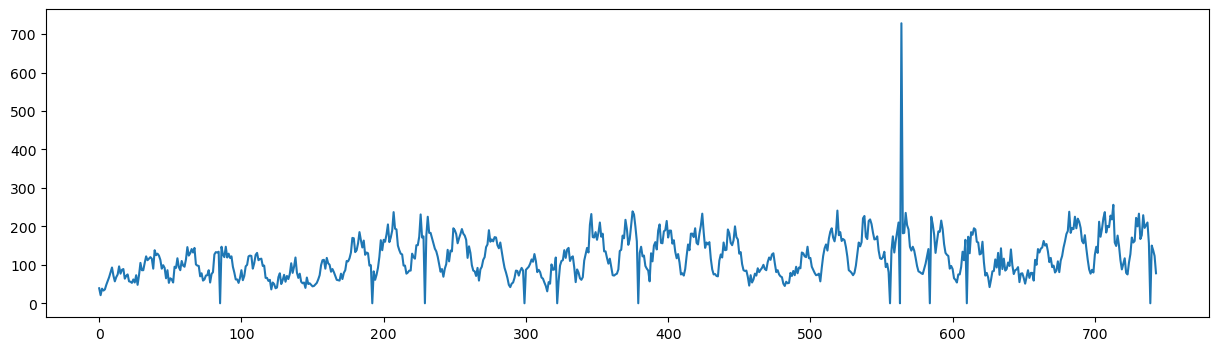

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x)
plt.show()

In [5]:
import numpy as np

def ar(y, d):
    t = y.shape[0]
    vec = y[d :] # T-d
    mat = np.vstack([y[d-i-1 : t-i-1] for i in range(d)]).T # (T-d) x d
    return np.linalg.pinv(mat) @ vec

def time_series_pred(data, coef, horizon):
    t = data.shape[0]
    d = coef.shape[0]
    mat = np.vstack([data[t-horizon-i-1 : t-i-1] for i in range(d)]).T # h x d
    return mat @ coef

x = df.loc['Machine_learning'].values[: 24 * 31]
# x = df.loc['Bayesian_network'].values[: 24 * 31]

d = 168
coef = ar(x[: 24 * (31 - 14)], d)
horizon = 168
est = time_series_pred(x, coef, horizon)

pos = np.where(x[- horizon :] > 0)
print('MAPE: {:.6}'.format(compute_mape((x[- horizon :])[pos], est[pos])))
print('RMSE: {:.6}'.format(compute_rmse((x[- horizon :])[pos], est[pos])))
print()

MAPE: 0.524658
RMSE: 79.2307



In [6]:
import numpy as np

x = df.loc['Bayesian_network'].values[: 24 * 31]
mape = 0
rmse = 0
num = 100
degree = 7
for i in range(num):
    np.random.seed(i)
    rng = np.random.default_rng()
    noise = rng.standard_t(degree, size=(24 * (31 - 7)))
    
    d = 168
    coef = ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d)
    horizon = 168
    est = time_series_pred(x, coef, horizon)
    
    pos = np.where(x[- horizon :] > 0)
    mape += compute_mape((x[- horizon :])[pos], est[pos])
    rmse += compute_rmse((x[- horizon :])[pos], est[pos])
print('MAPE: {:.6}'.format(mape / num))
print('RMSE: {:.6}'.format(rmse / num))
print()

MAPE: 0.562206
RMSE: 9.20706



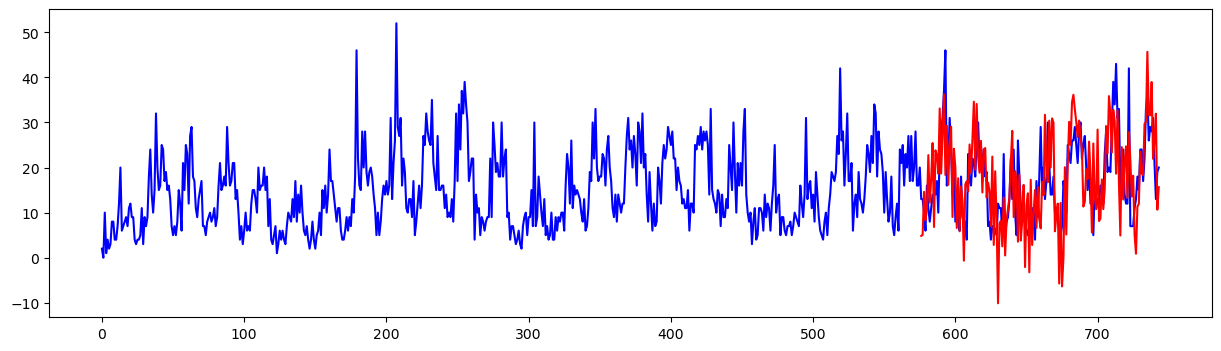

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
# x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x, 'b-')
plt.plot(np.arange(24 * 24, 31 * 24), est, 'r-')
plt.show()

In [8]:
import cvxpy as cp
import numpy as np

def huber_ar(y, d, delta = 1, solver = cp.ECOS):
    t = y.shape[0]
    vec = y[d :] # T-d
    mat = np.vstack([y[d-i-1 : t-i-1] for i in range(d)]).T # (T-d) x d

    coef = cp.Variable(d)
    residual = vec - mat @ coef
    obj = cp.sum(cp.huber(residual, delta))
    prob = cp.Problem(cp.Minimize(obj))
    prob.solve(solver = solver)

    return coef.value

def log_huber_ar(y, d, delta = 1, max_iter = 20):
    t = y.shape[0]
    vec = y[d :] # T-d
    mat = np.vstack([y[d-i-1 : t-i-1] for i in range(d)]).T # (T-d) x d
    theta = np.ones(t - d)
    for _ in range(max_iter):
        xt_w = mat.T * theta
        lhs = xt_w @ mat
        rhs = xt_w @ vec
        # w = np.linalg.pinv(lhs) @ rhs
        try:
            w = np.linalg.solve(lhs, rhs)
        except: #np.linalg.LinAlgError:
            w = np.linalg.lstsq(lhs, rhs, rcond = None)[0]
        epsilon = vec - mat @ w
        abs_eps = np.abs(epsilon)
        pos = np.where(abs_eps > delta)
        theta = np.ones(epsilon.shape)
        theta[pos] = delta ** 2 / abs_eps[pos] ** 2
        # theta = np.where(abs_eps <= delta, 1.0, delta / abs_eps)
    return w

def time_series_pred(data, coef, horizon):
    t = data.shape[0]
    d = coef.shape[0]
    mat = np.vstack([data[t-horizon-i-1 : t-i-1] for i in range(d)]).T # h x d
    return mat @ coef

(CVXPY) Aug 15 06:54:03 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Aug 15 06:54:03 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


In [9]:
x = df.loc['Machine_learning'].values[: 24 * 31]
d = 168
for delta in range(1, 50, 1):
    coef = huber_ar(x[: 24 * (31 - 14)], d, delta)
    horizon = 168
    data = x[: - 24 * 7]
    est = time_series_pred(data, coef, horizon)

    pos = np.where(data[- horizon :] > 0)
    print('Huber threshold: {}'.format(delta))
    print('MAPE: {:.6}'.format(compute_mape((data[- horizon :])[pos], est[pos])))
    print('RMSE: {:.6}'.format(compute_rmse((data[- horizon :])[pos], est[pos])))
    print()

/opt/anaconda3/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


Huber threshold: 1
MAPE: 0.322958
RMSE: 61.4238

Huber threshold: 2
MAPE: 0.323412
RMSE: 61.5523

Huber threshold: 3
MAPE: 0.322465
RMSE: 61.4328

Huber threshold: 4
MAPE: 0.315626
RMSE: 61.1264

Huber threshold: 5
MAPE: 0.313767
RMSE: 61.1106

Huber threshold: 6
MAPE: 0.311939
RMSE: 61.1377

Huber threshold: 7
MAPE: 0.312224
RMSE: 61.1408

Huber threshold: 8
MAPE: 0.310918
RMSE: 61.0164

Huber threshold: 9
MAPE: 0.30786
RMSE: 60.8238

Huber threshold: 10
MAPE: 0.304092
RMSE: 60.5757

Huber threshold: 11
MAPE: 0.301474
RMSE: 60.4064

Huber threshold: 12
MAPE: 0.299489
RMSE: 60.2931

Huber threshold: 13
MAPE: 0.296821
RMSE: 60.1333

Huber threshold: 14
MAPE: 0.294084
RMSE: 59.9462

Huber threshold: 15
MAPE: 0.29171
RMSE: 59.8092

Huber threshold: 16
MAPE: 0.289746
RMSE: 59.6706

Huber threshold: 17
MAPE: 0.288367
RMSE: 59.5496

Huber threshold: 18
MAPE: 0.286765
RMSE: 59.4302

Huber threshold: 19
MAPE: 0.286185
RMSE: 59.3515

Huber threshold: 20
MAPE: 0.286559
RMSE: 59.382

Huber thresh

In [10]:
# x = df.loc['Machine_learning'].values[: 24 * 31]
d = 168
delta = 19
coef = huber_ar(x[: 24 * (31 - 14)], d, delta)
horizon = 168
est = time_series_pred(x, coef, horizon)

pos = np.where(x[- horizon :] > 0)
print('Huber threshold: {}'.format(delta))
print('MAPE: {:.6}'.format(compute_mape((x[- horizon :])[pos], est[pos])))
print('RMSE: {:.6}'.format(compute_rmse((x[- horizon :])[pos], est[pos])))
print()

Huber threshold: 19
MAPE: 0.441117
RMSE: 66.1377



/opt/anaconda3/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


In [11]:
import numpy as np

x = df.loc['Machine_learning'].values[: 24 * 31]
delta = 19
# x = df.loc['Bayesian_network'].values[: 24 * 31]
# delta = 5
mape = 0
rmse = 0
num = 100
degree = 7
for i in range(num):
    np.random.seed(i)
    rng = np.random.default_rng()
    noise = rng.standard_t(degree, size=(24 * (31 - 7)))
    
    d = 168
    # coef = huber_ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d, delta)
    coef = log_huber_ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d, delta)
    horizon = 168
    est = time_series_pred(x, coef, horizon)
    
    pos = np.where(x[- horizon :] > 0)
    mape += compute_mape((x[- horizon :])[pos], est[pos])
    rmse += compute_rmse((x[- horizon :])[pos], est[pos])
print('MAPE: {:.6}'.format(mape / num))
print('RMSE: {:.6}'.format(rmse / num))
print()

MAPE: 0.447531
RMSE: 64.3387



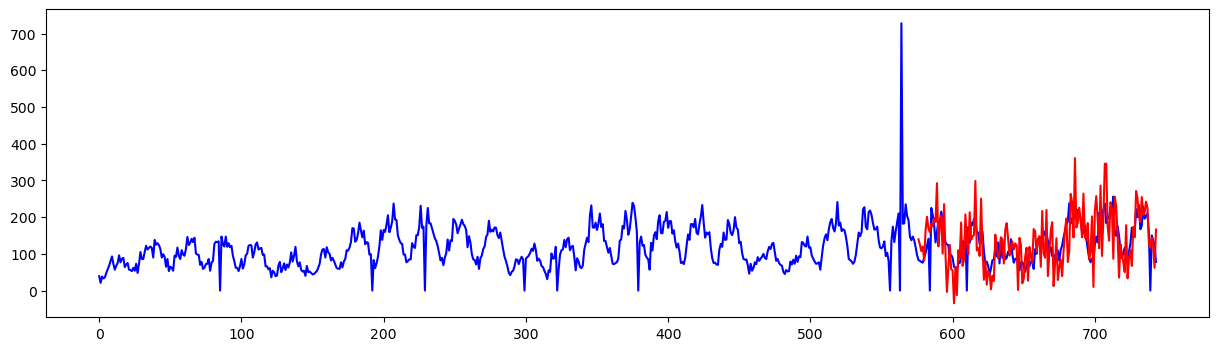

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
# x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x, 'b-')
plt.plot(np.arange(24 * 24, 31 * 24), est, 'r-')
plt.show()

In [9]:
import numpy as np

def robust_ar(y, d, delta = 1, p = 0, max_iter = 20):
    t = y.shape[0]
    vec = y[d :] # T-d
    mat = np.vstack([y[d-i-1 : t-i-1] for i in range(d)]).T # (T-d) x d
    theta = np.ones(t - d)
    for _ in range(max_iter):
        xt_w = mat.T * theta
        lhs = xt_w @ mat
        rhs = xt_w @ vec
        # w = np.linalg.pinv(lhs) @ rhs
        try:
            w = np.linalg.solve(lhs, rhs)
        except: #np.linalg.LinAlgError:
            w = np.linalg.lstsq(lhs, rhs, rcond = None)[0]
        epsilon = vec - mat @ w
        abs_eps = np.abs(epsilon)
        pos = np.where(abs_eps > delta)
        theta = np.ones(epsilon.shape)
        theta[pos] = delta ** (2 - p) / (np.abs(epsilon[pos]) ** (2 - p))
    return w

def time_series_pred(data, coef, horizon):
    t = data.shape[0]
    d = coef.shape[0]
    mat = np.vstack([data[t-horizon-i-1 : t-i-1] for i in range(d)]).T # h x d
    return mat @ coef

In [10]:
x = df.loc['Machine_learning'].values[: 24 * 31]
d = 168
p = 2/3
for delta in range(1, 50, 1):
    coef = robust_ar(x[: 24 * (31 - 14)], d, delta, p)
    horizon = 168
    data = x[: - 24 * 7]
    est = time_series_pred(data, coef, horizon)

    pos = np.where(data[- horizon :] > 0)
    print('Huber threshold: {}'.format(delta))
    print('MAPE: {:.6}'.format(compute_mape((data[- horizon :])[pos], est[pos])))
    print('RMSE: {:.6}'.format(compute_rmse((data[- horizon :])[pos], est[pos])))
    print()

Huber threshold: 1
MAPE: 0.353363
RMSE: 64.8881

Huber threshold: 2
MAPE: 0.341894
RMSE: 64.5392

Huber threshold: 3
MAPE: 0.333892
RMSE: 62.6965

Huber threshold: 4
MAPE: 0.310442
RMSE: 60.9671

Huber threshold: 5
MAPE: 0.316634
RMSE: 61.6042

Huber threshold: 6
MAPE: 0.301732
RMSE: 60.6178

Huber threshold: 7
MAPE: 0.307594
RMSE: 61.1301

Huber threshold: 8
MAPE: 0.314082
RMSE: 61.5091

Huber threshold: 9
MAPE: 0.319024
RMSE: 61.5089

Huber threshold: 10
MAPE: 0.314604
RMSE: 61.0582

Huber threshold: 11
MAPE: 0.307493
RMSE: 60.5373

Huber threshold: 12
MAPE: 0.301272
RMSE: 60.1613

Huber threshold: 13
MAPE: 0.293641
RMSE: 59.5029

Huber threshold: 14
MAPE: 0.285114
RMSE: 58.8067

Huber threshold: 15
MAPE: 0.282907
RMSE: 58.4966

Huber threshold: 16
MAPE: 0.283218
RMSE: 58.4056

Huber threshold: 17
MAPE: 0.285148
RMSE: 58.3786

Huber threshold: 18
MAPE: 0.28477
RMSE: 58.3112

Huber threshold: 19
MAPE: 0.282685
RMSE: 58.1955

Huber threshold: 20
MAPE: 0.28066
RMSE: 58.1141

Huber thres

In [12]:
d = 168
delta = 19
coef = robust_ar(x[: 24 * (31 - 14)], d, delta, p)
horizon = 168
est = time_series_pred(x, coef, horizon)

pos = np.where(x[- horizon :] > 0)
print('Huber threshold: {}'.format(delta))
print('MAPE: {:.6}'.format(compute_mape((x[- horizon :])[pos], est[pos])))
print('RMSE: {:.6}'.format(compute_rmse((x[- horizon :])[pos], est[pos])))
print()

Huber threshold: 19
MAPE: 0.43256
RMSE: 63.1553



In [73]:
import numpy as np

# x = df.loc['Machine_learning'].values[: 24 * 31]
# delta = 19
x = df.loc['Bayesian_network'].values[: 24 * 31]
delta = 5
p = 0
mape = 0
rmse = 0
num = 1000
degree = 11
for i in range(num):
    np.random.seed(i)
    rng = np.random.default_rng()
    noise = rng.standard_t(degree, size=(24 * (31 - 7)))
    
    d = 168
    # coef = robust_ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d, delta, p)
    # coef = huber_ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d, delta)
    coef = ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d)
    horizon = 168
    est = time_series_pred(x, coef, horizon)
    
    pos = np.where(x[- horizon :] > 0)
    mape += compute_mape((x[- horizon :])[pos], est[pos])
    rmse += compute_rmse((x[- horizon :])[pos], est[pos])
print('MAPE: {:.6}'.format(mape / num))
print('RMSE: {:.6}'.format(rmse / num))
print()

MAPE: 0.567944
RMSE: 9.28662

